# **`Inatel - C24 (Inteligência Artificial) - 2026/1`**

# <font color='green'>**Atividade 08: RNN**</font>

## <font color='#2D9CDB'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte o material disponibilizado pelo Prof. Felipe Figueiredo para revisar os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**A ATIVIDADE DEVERÁ SER REALIZADA COM O [MONITOR](mailto:matheus.botelho@ges.inatel.br) EM UM DOS SEGUINTES HORÁRIOS:**</font>

| Monitor                       | Dia           | Hora                               | Local           |
|-------------------------------|---------------|------------------------------------|---------------- |
| Matheus Botelho Sampaio Netto | Terça-feira   | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Quinta-feira  | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>10:00</font> | Teams (ao vivo) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>13:30</font> | Teams (ao vivo) |

- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='#2D9CDB'>azul</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação.</font>
  - Exemplo: `!pip install nome_da_biblioteca`
- <font color='red'>**Renomeie os termos `LL` para `sua_turma_de_laboratorio` e `MMMM` para `seu_numero_de_matricula` no nome do arquivo.**</font>
  - Exemplo: `C24_2026_1_L1_Atividade_08_1234.ipynb`)
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

# <font color='green'><u><b>Preparação</b></u></font>

In [1]:
!pip install tensorflow numpy pandas matplotlib seaborn scikit-learn

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tensorflow as tf
import os

from sklearn.preprocessing import MinMaxScaler

tf.random.set_seed(42)
np.random.seed(42)

# <font color='green'><u><b>Parte 1 - Conjunto de Dados</b></u></font>

 ´Não altere o conteúdo da célula a seguir!łł”v

In [3]:
zip_path = tf.keras.utils.get_file(
    fname="jena_climate_2009_2016.csv.zip",
    origin="https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip",
    cache_dir=os.getcwd(),
    extract=True
)

csv_path = os.path.join(os.path.splitext(zip_path)[0], 'jena_climate_2009_2016.csv')

target_col = "T (degC)"

temperature = pd.read_csv(csv_path)[target_col].values.reshape(-1, 1)

temperature

13568290/13568290 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


array([[-8.02],
       [-8.41],
       [-8.51],
       ...,
       [-3.16],
       [-4.23],
       [-4.82]])

### <font color='#2D9CDB'>Q1) O dataset [Jena Climate](https://www.kaggle.com/datasets/mnassrib/jena-climate) é amplamente utilizado no estudo de redes neurais recorrentes (RNNs), LSTMs e previsão de séries temporais. Pesquise brevemente sobre o dataset e descreva, em um único parágrafo, o domínio de aplicação da base de dados, o objetivo para o qual ela foi criada, o período de coleta dos dados, os tipos de variáveis meteorológicas registradas e por que esse conjunto de dados é adequado para problemas de previsão temporal utilizando redes neurais recorrentes.</font>

`Jena Climate` é um dataset de séries temporais com foco no clima. Ele é composto de 14 diferentes variáveis quantitativas, como temperatura do ar e pressão atmosférica. É prioritariamente utilizado para aprendizado. Os dados foram coletados a cada 10 minutos, por alguns anos. É adequado porque ele se comporta exatamente como os problemas do mundo real que as RNNs foram feitas para resolver: é contínuo, multivariado e possui memória de curto e longo prazo com base no tempo de coleta.

### <font color='#2D9CDB'>Q2) Utilizando a variável <code>temperature</code>, plote a série temporal completa de temperaturas registradas no dataset. Em seguida, informe a quantidade total de amostras, a temperatura mínima, a temperatura máxima, a temperatura média e o desvio padrão da série. Com base no gráfico obtido, descreva brevemente os padrões observados, comentando sobre possíveis tendências, sazonalidades e variações ao longo do tempo.</font>

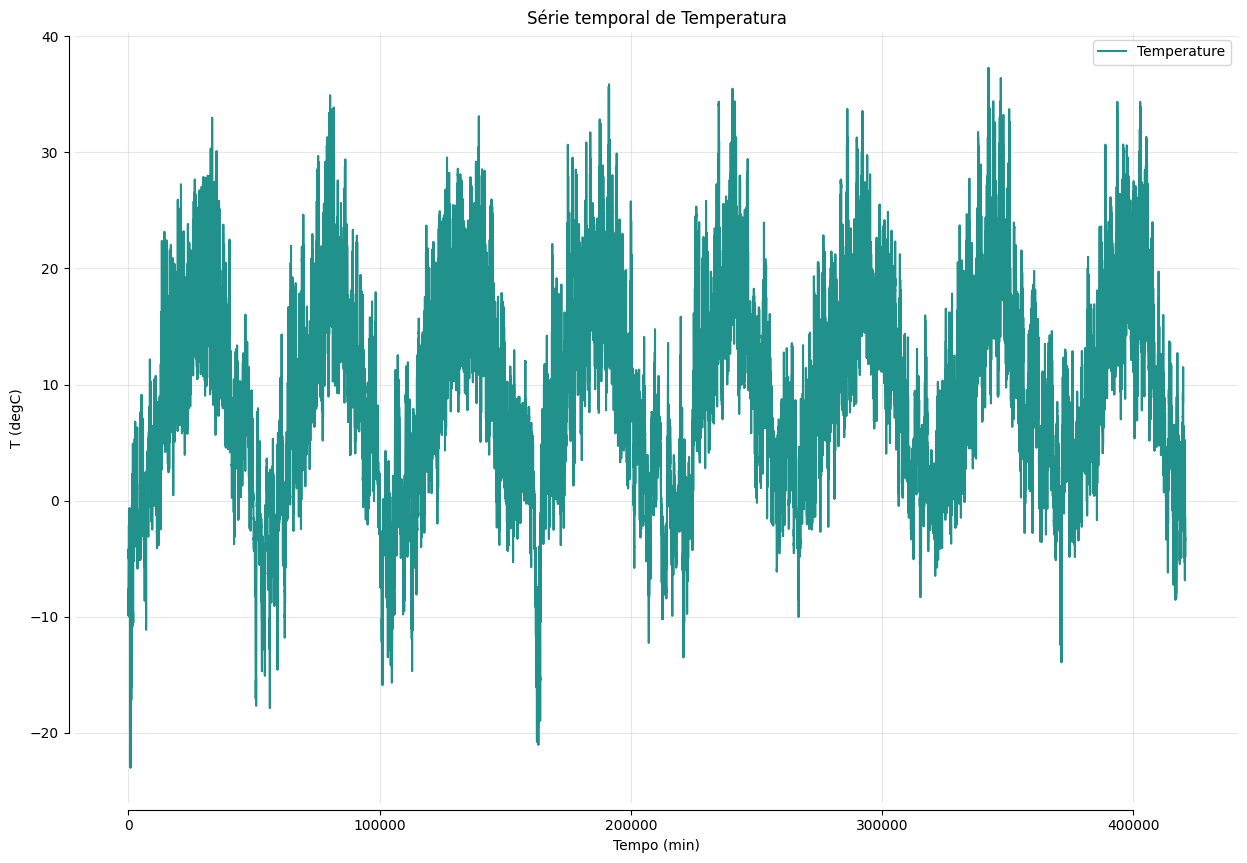

----------------------------------------------------------------------------------------------------
Quantidade de amostras: 420551
Temperatura mínima: -23.01 °C
Temperatura máxima: 37.28 °C
Temperatura média: 9.450147354304233 °C
Desvio padrão: 8.423355195701777


In [4]:
plt.figure(figsize=(15, 10))
sns.lineplot(data=temperature, palette='viridis')
sns.despine(offset = 5, trim=True)
plt.title(f"Série temporal de Temperatura")
plt.xlabel("Tempo (min)")
plt.ylabel(target_col)
plt.grid(True, alpha=0.3)
plt.legend(['Temperature'])
plt.show()

print('-' * 100)

print(f"Quantidade de amostras: {len(temperature)}")
print(f"Temperatura mínima: {temperature.min()} °C")
print(f"Temperatura máxima: {temperature.max()} °C")
print(f"Temperatura média: {temperature.mean()} °C")
print(f"Desvio padrão: {temperature.std()}")


Essa Série Temporal apresenta marcante sazonalidade - presença de 8 picos semelhantes em regiões específicas (sazonalidade anual). Ela possui tendência estacionária (não possui tendência de alta ou baixa continuamente a longo prazo). Alguns outliers podem ser observados como as quedas abruptas próximas aos tempos 0 e 160000, onde a temperatura despencou para -20°C de forma atípica.

### <font color='#2D9CDB'>Q3) Divida a série temporal em três subconjuntos: treinamento (60%), validação (20%) e teste (20%), preservando a ordem temporal das amostras. Informe a quantidade de amostras em cada subconjunto e explique por que, em problemas de previsão temporal, não é adequado embaralhar os dados antes da divisão.</font>

In [5]:
total_sample = len(temperature)
n_train = int(0.6 * total_sample)
n_val = n_train + int(0.2 * total_sample)

_train = temperature[:n_train]
_val = temperature[n_train:n_val]
_test = temperature[n_val:]

print(f"Quantidade de amostras de treinamento: {len(_train)}")
print(f"Quantidade de amostras de validação: {len(_val)}")
print(f"Quantidade de amostras de teste: {len(_test)}")

Quantidade de amostras de treinamento: 252330
Quantidade de amostras de validação: 84110
Quantidade de amostras de teste: 84111


Usar train_test_split é incorreto nesse caso pois embaralharia os valores da série temporal. Embaralhar os dados antes da divisão é perigoso pois pode causa data leakage (valores dependentes do tempo tem autocorrelação), assim como padrões temporais seriam perdidos e impedindo um bom modelo de generalizar.

### <font color='#2D9CDB'>Q4) Normalize os conjuntos de treinamento, validação e teste utilizando a técnica Min-Max Scaling, de forma que os valores fiquem no intervalo [0, 1]. Apresente os valores mínimo e máximo do conjunto de treinamento antes e depois da normalização e explique brevemente por que a normalização é importante para o treinamento de redes neurais.</font>

In [6]:
print(f"Valor mínino antes:{_train.min()} °C")
print(f"Valor máximo antes:{_train.max()} °C")

scaler = MinMaxScaler(feature_range=(0, 1))

s_train = scaler.fit_transform(_train)
s_val = scaler.transform(_val)
s_test = scaler.transform(_test)

print(f"Valor mínimo depois:{s_train.min()}")
print(f"Valor máximo depois:{s_train.max()}")



Valor mínino antes:-23.01 °C
Valor máximo antes:35.86 °C
Valor mínimo depois:0.0
Valor máximo depois:1.0


A normalização é importante pois é essencial para garantir maior velocidade de convergência do gradiente descendente, assim como é essencial para garantir as funcionalidades corretas de algoritmos baseados em distância, como KNN e PCA.

# <font color='green'><u><b>Parte 2 - Preparação das Séries Temporais</b></u></font>

### <font color='#2D9CDB'>Q5) Para treinar uma LSTM, é necessário organizar a série temporal em sequências de entrada e saídas desejadas. Implemente uma função chamada <code>create_sequences()</code> que utilize uma janela temporal de 30 amostras, de forma que cada entrada seja composta pelas 30 temperaturas anteriores e a saída corresponda à temperatura seguinte. Gere os conjuntos de treinamento, validação e teste e informe as dimensões de <code>X_train</code> e <code>y_train</code>. Explique brevemente o significado de cada dimensão.</font>

In [7]:
LOOKBACK = 30
def create_sequences(temperature, lookback):
  X, y = [], []
  for i in range(len(temperature) - lookback):
    X.append(temperature[i : i + lookback])
    y.append(temperature[i + lookback])
  return np.array(X), np.array(y)

x_train, y_train = create_sequences(s_train, LOOKBACK)
x_val, y_val = create_sequences(s_val, LOOKBACK)
x_test, y_test = create_sequences(s_test, LOOKBACK)

print(x_train.shape)
print(y_train.shape)

(252300, 30, 1)
(252300, 1)


A primeira dimensão indica quantidade de amostras. A segunda dimensão em X é `timesteps` que indica o tamanho da memória (Lookback) e a última dimensão indica quantidade de atributos, nesse caso, somente a temperatura.

### <font color='#2D9CDB'>Q6) Exiba graficamente a primeira sequência presente em <code>X_train</code> e destaque o valor correspondente em <code>y_train</code>. Explique como essa sequência será utilizada pela LSTM para realizar a previsão da próxima temperatura.</font>

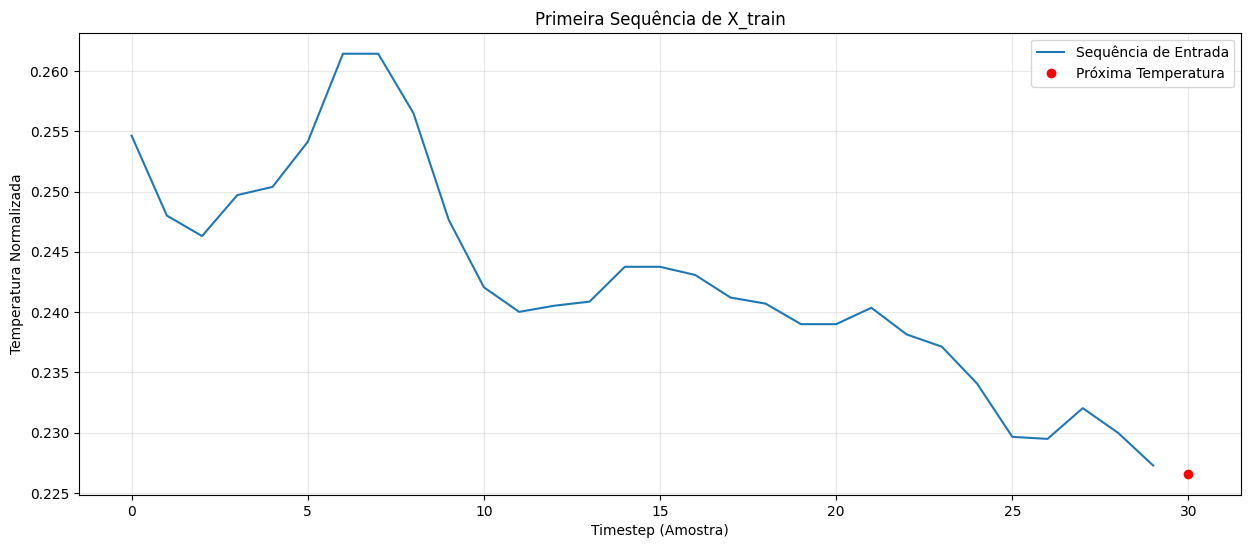

In [8]:
first_sequence = x_train[0]
first_label = y_train[0]

plt.figure(figsize=(15, 6))
plt.plot(range(LOOKBACK), first_sequence, label='Sequência de Entrada')
plt.plot(LOOKBACK, first_label, 'ro', label='Próxima Temperatura')
plt.title('Primeira Sequência de X_train')
plt.xlabel('Timestep (Amostra)')
plt.ylabel('Temperatura Normalizada')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

O modelo LSTM receberá a sequência de 30 temperaturas normalizadas como entrada e tentará prever a próxima temperatura. No gráfico acima, a linha azul representa as 30 temperaturas anteriores, e o ponto vermelho representa a temperatura que a LSTM tentará prever com base nessa sequência.

# <font color='green'><u><b>Parte 3 - Construindo a Primeira LSTM</b></u></font>

### <font color='#2D9CDB'>Q7) Construa uma rede neural recorrente composta por uma camada LSTM com uma unidade de memória e uma camada de saída totalmente conectada com um neurônio. Utilize a função de perda MSE (<code>mean_squared_error</code>) e o otimizador Adam. Apresente o resumo da arquitetura gerado pelo método <code>summary()</code> e informe o número total de parâmetros treináveis do modelo.</font>

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input

In [10]:
model = Sequential([
    Input(shape=(LOOKBACK, 1)),
    LSTM(1),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14 (56.00 B)

 Trainable params: 14 (56.00 B)

 Non-trainable params: 0 (0.00 B)

14 Parâmetros treináveis.

### <font color='#2D9CDB'>Q8) Treine o modelo por 10 épocas utilizando os conjuntos de treinamento e validação. Em seguida, plote as curvas de perda de treinamento e validação ao longo das épocas. Com base nos gráficos obtidos, descreva brevemente o comportamento do treinamento e indique se há evidências de sobreajuste (overfitting) ou problemas de generalização.</font>

In [11]:
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(x_val, y_val)
)

Epoch 1/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 51s 6ms/step - loss: 4.6710e-04 - val_loss: 7.1372e-05
Epoch 2/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 47s 6ms/step - loss: 4.7506e-05 - val_loss: 3.1106e-05
Epoch 3/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 47s 6ms/step - loss: 2.8220e-05 - val_loss: 2.2498e-05
Epoch 4/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 81s 6ms/step - loss: 2.1800e-05 - val_loss: 1.9231e-05
Epoch 5/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 47s 6ms/step - loss: 1.8667e-05 - val_loss: 1.7450e-05
Epoch 6/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 47s 6ms/step - loss: 1.6887e-05 - val_loss: 1.6287e-05
Epoch 7/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 47s 6ms/step - loss: 1.5820e-05 - val_loss: 1.5524e-05
Epoch 8/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 47s 6ms/step - loss: 1.5184e-05 - val_loss: 1.5045e-05
Epoch 9/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 47s 6ms/step - loss: 1.4822e-05 - val_loss: 1.4757e-05
Epoch 10/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 47s 6ms/step - loss: 1.4624e-05 - val_loss: 1.4585e-05


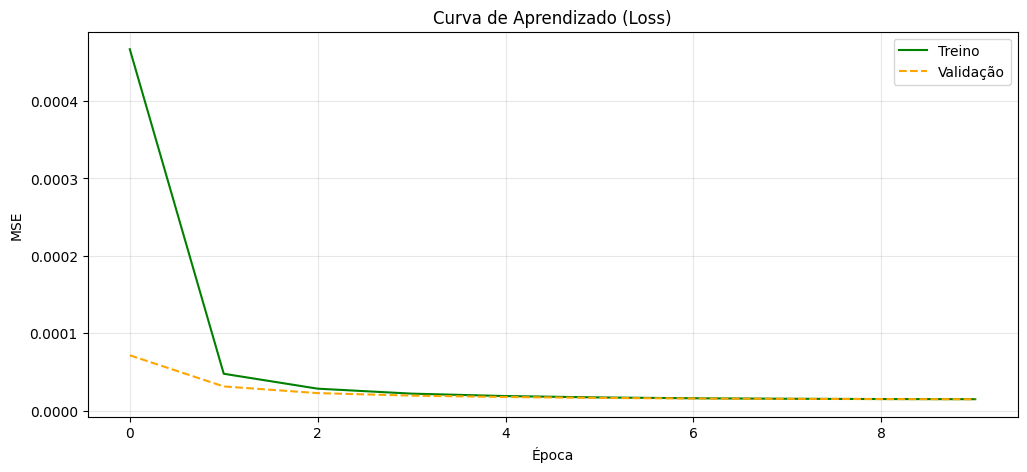

In [12]:
plt.figure(figsize=(12,5))

plt.plot(history.history['loss'], label='Treino', color='green')
plt.plot(history.history['val_loss'], label='Validação', color='orange', linestyle='--')
plt.title("Curva de Aprendizado (Loss)")
plt.xlabel("Época")
plt.ylabel("MSE")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


Pelo gráfico, podemos notar que o modelo consegue generalizar bem. Mas vale salientar que o valor baixo inicial do conjunto de validação pode indicar subajuste.

### <font color='#2D9CDB'>Q9) Avalie o modelo utilizando o conjunto de teste e reporte o valor do erro quadrático médio (MSE). Em seguida, explique brevemente o que essa métrica representa no contexto do problema de previsão de temperatura.</font>

In [13]:
from sklearn.metrics import mean_squared_error

In [14]:
y_pred_norm = model.predict(x_test)

# Desnormalizar para a escala original
y_pred = scaler.inverse_transform(y_pred_norm)
y_real = scaler.inverse_transform(y_test)

mse_test_1u = mean_squared_error(y_real, y_pred)
print(f"O Erro Quadrático Médio (MSE) no conjunto de teste é: {mse_test_1u:.6f}")

2628/2628 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
O Erro Quadrático Médio (MSE) no conjunto de teste é: 0.054440


o Erro Quadrático Médio (MSE) representa a qualidade global das previsões da rede LSTM, quantificando o quão distantes as temperaturas previstas estão das temperaturas reais.

### <font color='#2D9CDB'>Q10) Utilize o modelo treinado para gerar previsões no conjunto de teste. Plote em um mesmo gráfico os valores reais e previstos para as 100 primeiras amostras do conjunto de teste e descreva brevemente a qualidade das previsões obtidas.</font>

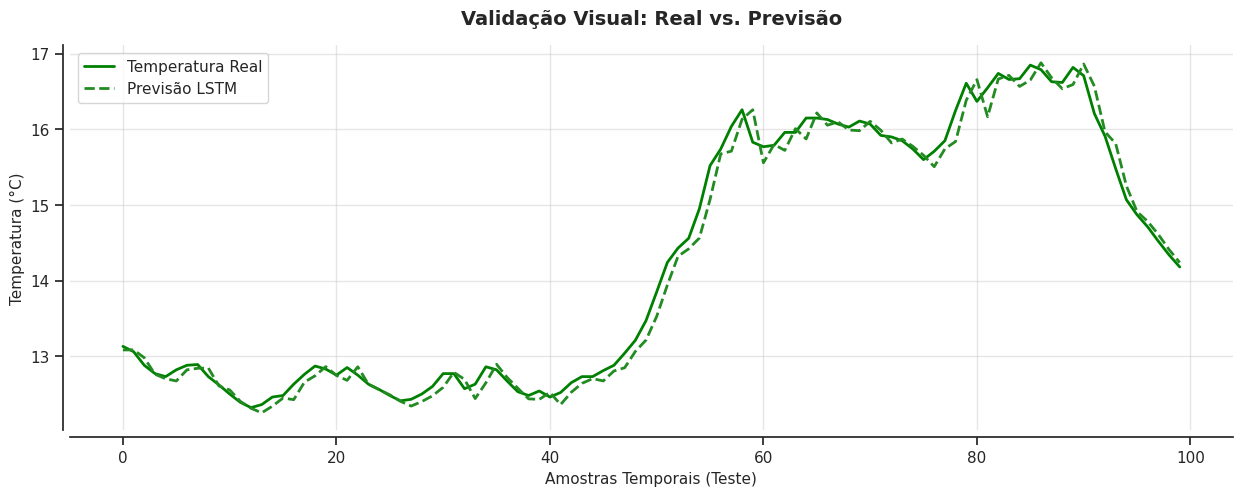

In [15]:
sns.set_theme(style="ticks")
plt.figure(figsize=(15, 5))

plt.plot(y_real[:100], color='green', linewidth=2, label='Temperatura Real')
plt.plot(y_pred[:100], color='forestgreen', linestyle='--', linewidth=2, label='Previsão LSTM')

sns.despine(offset=5)
plt.title("Validação Visual: Real vs. Previsão", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Amostras Temporais (Teste)", fontsize=11)
plt.ylabel("Temperatura (°C)", fontsize=11)
plt.grid(True, alpha=0.5)

plt.legend()
plt.show()

Observando o gráfico e o valor do erro na questão anterior, podemos dizer que o modelo está generalizando bem: o dados da previsão estão muito próximos da temperatura real.

# <font color='green'><u><b>Parte 4 - Comparação de Arquiteturas</b></u></font>

### <font color='#2D9CDB'>Q11) Modifique a arquitetura da rede para utilizar 10 unidades na camada LSTM. Apresente o resumo da arquitetura gerado pelo método <code>summary()</code> e informe o número total de parâmetros treináveis do modelo. Em seguida, treine a rede por 10 épocas, avalie o modelo no conjunto de teste e reporte o valor de MSE obtido.</font>

In [16]:
model_10 = Sequential([
    Input(shape=(LOOKBACK, 1)),
    LSTM(10),
    Dense(1)
])

model_10.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

model_10.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 10)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 491 (1.92 KB)

 Trainable params: 491 (1.92 KB)

 Non-trainable params: 0 (0.00 B)

491 Parâmetros treináveis.

In [17]:
history_10 = model_10.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(x_val, y_val)
)

Epoch 1/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 50s 6ms/step - loss: 6.8262e-04 - val_loss: 2.8078e-05
Epoch 2/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 49s 6ms/step - loss: 2.4098e-05 - val_loss: 1.5928e-05
Epoch 3/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 49s 6ms/step - loss: 1.6266e-05 - val_loss: 1.2408e-05
Epoch 4/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 49s 6ms/step - loss: 1.4153e-05 - val_loss: 1.2916e-05
Epoch 5/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 82s 6ms/step - loss: 1.3897e-05 - val_loss: 1.4124e-05
Epoch 6/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 49s 6ms/step - loss: 1.3755e-05 - val_loss: 1.3006e-05
Epoch 7/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 81s 6ms/step - loss: 1.3644e-05 - val_loss: 1.1744e-05
Epoch 8/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 48s 6ms/step - loss: 1.3541e-05 - val_loss: 1.1364e-05
Epoch 9/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 56s 7ms/step - loss: 1.3443e-05 - val_loss: 1.1399e-05
Epoch 10/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 49s 6ms/step - loss: 1.3359e-05 - val_loss: 1.1502e-05


In [18]:
y_pred_norm = model_10.predict(x_test)

# Desnormalizar para a escala original
y_pred = scaler.inverse_transform(y_pred_norm)
y_real = scaler.inverse_transform(y_test)

mse_test_10u = mean_squared_error(y_real, y_pred)
print(f"O Erro Quadrático Médio (MSE) no conjunto de teste é: {mse_test_10u:.6f}")

2628/2628 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
O Erro Quadrático Médio (MSE) no conjunto de teste é: 0.042685


### <font color='#2D9CDB'>Q12) Repita o experimento utilizando 20 unidades na camada LSTM. Apresente o resumo da arquitetura gerado pelo método <code>summary()</code> e informe o número total de parâmetros treináveis do modelo. Em seguida, treine a rede por 10 épocas, avalie o modelo no conjunto de teste e reporte o valor de MSE obtido.</font>

In [19]:
model_20 = Sequential([
    Input(shape=(LOOKBACK, 1)),
    LSTM(20),
    Dense(1)
])

model_20.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

model_20.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 20)             │         1,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,781 (6.96 KB)

 Trainable params: 1,781 (6.96 KB)

 Non-trainable params: 0 (0.00 B)

1781 Parâmetros treináveis.

In [20]:
history_20 = model_20.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(x_val, y_val)
)

Epoch 1/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 50s 6ms/step - loss: 3.3366e-04 - val_loss: 3.1767e-05
Epoch 2/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 82s 6ms/step - loss: 2.3750e-05 - val_loss: 1.3394e-05
Epoch 3/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 49s 6ms/step - loss: 1.4274e-05 - val_loss: 1.4030e-05
Epoch 4/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 49s 6ms/step - loss: 1.3705e-05 - val_loss: 1.1459e-05
Epoch 5/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 82s 6ms/step - loss: 1.3449e-05 - val_loss: 1.1623e-05
Epoch 6/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 49s 6ms/step - loss: 1.3281e-05 - val_loss: 1.1957e-05
Epoch 7/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 49s 6ms/step - loss: 1.3165e-05 - val_loss: 1.1845e-05
Epoch 8/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 49s 6ms/step - loss: 1.3070e-05 - val_loss: 1.1710e-05
Epoch 9/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 49s 6ms/step - loss: 1.2998e-05 - val_loss: 1.1592e-05
Epoch 10/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 49s 6ms/step - loss: 1.2949e-05 - val_loss: 1.1525e-05


In [21]:
y_pred_norm = model_20.predict(x_test)

# Desnormalizar para a escala original
y_pred = scaler.inverse_transform(y_pred_norm)
y_real = scaler.inverse_transform(y_test)

mse_test_20u = mean_squared_error(y_real, y_pred)
print(f"O Erro Quadrático Médio (MSE) no conjunto de teste é: {mse_test_20u:.6f}")

2628/2628 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
O Erro Quadrático Médio (MSE) no conjunto de teste é: 0.042821


### <font color='#2D9CDB'>Q13) Compare os modelos com 1, 10 e 20 unidades na camada LSTM em termos de número de parâmetros treináveis e desempenho no conjunto de teste. Organize os resultados em uma tabela contendo a quantidade de unidades LSTM, o número de parâmetros treináveis e o valor de MSE. Com base nos resultados obtidos, discuta brevemente a relação entre a complexidade do modelo e sua capacidade preditiva.</font>

In [22]:
df_lstmunit = pd.DataFrame({
    'Unidades LSTM': [1, 10, 20],
    'Parâmetros Treináveis': [14, 491, 1781],
    'MSE Teste Real': [mse_test_1u, mse_test_10u, mse_test_20u]
})

tabela_final = (df_lstmunit.style.format(
    {
        'Parâmetros Treináveis': '{:,}',
        'MSE Teste Real': '{:.6f}'
    })
    .hide(axis='index')
    # Destaque do modelo vencedor:
    .highlight_min(subset=['MSE Teste Real'], color='green')
)
tabela_final

Unidades LSTM,Parâmetros Treináveis,MSE Teste Real
1,14,0.054440
10,491,0.042685
20,"1,781",0.042821


O número de parâmetros treináveis da LSTM cresce de forma quadrática com o aumento do número de unidades. Ao passarmos de 1 para 20 unidades, o volume de pesos internos salta drasticamente de 14 para 1.781.

O modelo com apenas 1 unidade apresentou o maior erro no teste (0.065909).

Quando elevamos a complexidade para 20 unidades, o erro no conjunto de teste voltou a subir ligeiramente. Esse comportamento ilustra o início de um sobreajuste (overfitting).

# <font color='green'><u><b>Parte 5 - Influência da Janela Temporal</b></u></font>

### <font color='#2D9CDB'>Q14) Repita o experimento utilizando uma janela temporal de 15 amostras e uma camada LSTM com 10 unidades. Treine o modelo por 10 épocas, avalie o modelo no conjunto de teste e reporte o valor de MSE obtido.</font>

In [23]:
LOOKBACK = 15
x_train_15, y_train_15 = create_sequences(s_train, LOOKBACK)
x_val_15, y_val_15 = create_sequences(s_val, LOOKBACK)
x_test_15, y_test_15 = create_sequences(s_test, LOOKBACK)

print(x_train_15.shape)
print(y_train_15.shape)

(252315, 15, 1)
(252315, 1)


In [24]:
model_w15 = Sequential([
    Input(shape=(LOOKBACK, 1)),
    LSTM(10),
    Dense(1)
])

model_w15.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

model_w15.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 10)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 491 (1.92 KB)

 Trainable params: 491 (1.92 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
history_w15 = model_w15.fit(
    x_train_15, y_train_15,
    epochs=10,
    validation_data=(x_val_15, y_val_15)
)

Epoch 1/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 46s 6ms/step - loss: 4.8992e-04 - val_loss: 3.4081e-05
Epoch 2/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 45s 6ms/step - loss: 2.5194e-05 - val_loss: 1.5634e-05
Epoch 3/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 44s 6ms/step - loss: 1.5198e-05 - val_loss: 1.1736e-05
Epoch 4/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 45s 6ms/step - loss: 1.3938e-05 - val_loss: 1.6165e-05
Epoch 5/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 45s 6ms/step - loss: 1.3662e-05 - val_loss: 1.6882e-05
Epoch 6/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 83s 6ms/step - loss: 1.3541e-05 - val_loss: 1.4357e-05
Epoch 7/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 45s 6ms/step - loss: 1.3464e-05 - val_loss: 1.2437e-05
Epoch 8/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 46s 6ms/step - loss: 1.3380e-05 - val_loss: 1.1523e-05
Epoch 9/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 81s 6ms/step - loss: 1.3304e-05 - val_loss: 1.1385e-05
Epoch 10/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 45s 6ms/step - loss: 1.3255e-05 - val_loss: 1.1445e-05


In [26]:
y_pred_norm_w15 = model_w15.predict(x_test_15)

# Desnormalizar para a escala original
y_pred = scaler.inverse_transform(y_pred_norm_w15)
y_real = scaler.inverse_transform(y_test_15)

mse_test_w15 = mean_squared_error(y_real, y_pred)
print(f"O Erro Quadrático Médio (MSE) no conjunto de teste é: {mse_test_w15:.6f}")

2628/2628 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
O Erro Quadrático Médio (MSE) no conjunto de teste é: 0.042544


### <font color='#2D9CDB'>Q15) Repita o experimento utilizando uma janela temporal de 60 amostras e uma camada LSTM com 10 unidades. Treine o modelo por 10 épocas, avalie o modelo no conjunto de teste e reporte o valor de MSE obtido.</font>

In [27]:
LOOKBACK = 60
x_train_60, y_train_60 = create_sequences(s_train, LOOKBACK)
x_val_60, y_val_60 = create_sequences(s_val, LOOKBACK)
x_test_60, y_test_60 = create_sequences(s_test, LOOKBACK)

print(x_train_60.shape)
print(y_train_60.shape)

(252270, 60, 1)
(252270, 1)


In [28]:
model_w60 = Sequential([
    Input(shape=(LOOKBACK, 1)),
    LSTM(10),
    Dense(1)
])

model_w60.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

model_w60.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 10)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 491 (1.92 KB)

 Trainable params: 491 (1.92 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
history_w60 = model_w60.fit(
    x_train_60, y_train_60,
    epochs=10,
    validation_data=(x_val_60, y_val_60)
)

Epoch 1/10
7884/7884 ━━━━━━━━━━━━━━━━━━━━ 56s 7ms/step - loss: 2.5819e-04 - val_loss: 2.7378e-05
Epoch 2/10
7884/7884 ━━━━━━━━━━━━━━━━━━━━ 55s 7ms/step - loss: 2.0496e-05 - val_loss: 1.4759e-05
Epoch 3/10
7884/7884 ━━━━━━━━━━━━━━━━━━━━ 56s 7ms/step - loss: 1.4316e-05 - val_loss: 1.2570e-05
Epoch 4/10
7884/7884 ━━━━━━━━━━━━━━━━━━━━ 55s 7ms/step - loss: 1.3950e-05 - val_loss: 1.1835e-05
Epoch 5/10
7884/7884 ━━━━━━━━━━━━━━━━━━━━ 55s 7ms/step - loss: 1.3553e-05 - val_loss: 1.1535e-05
Epoch 6/10
7884/7884 ━━━━━━━━━━━━━━━━━━━━ 55s 7ms/step - loss: 1.3346e-05 - val_loss: 1.1430e-05
Epoch 7/10
7884/7884 ━━━━━━━━━━━━━━━━━━━━ 55s 7ms/step - loss: 1.3233e-05 - val_loss: 1.1404e-05
Epoch 8/10
7884/7884 ━━━━━━━━━━━━━━━━━━━━ 56s 7ms/step - loss: 1.3157e-05 - val_loss: 1.1361e-05
Epoch 9/10
7884/7884 ━━━━━━━━━━━━━━━━━━━━ 55s 7ms/step - loss: 1.3102e-05 - val_loss: 1.1357e-05
Epoch 10/10
7884/7884 ━━━━━━━━━━━━━━━━━━━━ 82s 7ms/step - loss: 1.3072e-05 - val_loss: 1.1530e-05


In [30]:
y_pred_norm_w60 = model_w60.predict(x_test_60)

# Desnormalizar para a escala original
y_pred = scaler.inverse_transform(y_pred_norm_w60)
y_real = scaler.inverse_transform(y_test_60)

mse_test_w60 = mean_squared_error(y_real, y_pred)
print(f"O Erro Quadrático Médio (MSE) no conjunto de teste é: {mse_test_w60:.6f}")

2627/2627 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step
O Erro Quadrático Médio (MSE) no conjunto de teste é: 0.042728


### <font color='#2D9CDB'>Q16) Compare os resultados obtidos para janelas temporais de 15, 30 e 60 amostras utilizando uma camada LSTM com 10 unidades. Organize os resultados em uma tabela contendo o tamanho da janela temporal, o valor de MSE e uma estimativa do tempo médio de treinamento por época (dica: utilize os valores exibidos nos logs de treinamento). Com base nos resultados, discuta brevemente o impacto do tamanho da janela temporal no desempenho e no custo computacional do modelo.</font>

In [31]:
df_lstmw = pd.DataFrame({
    'Tamanhos Janela Temporal': [15, 30, 60],
    'MSE Teste Real': [mse_test_w15, mse_test_10u, mse_test_w60],
    'Estimativa do tempo médio': ['51s', '50s', '41s']
})

tabela_final = (df_lstmw.style.format(
    {
        'MSE Teste Real': '{:.6f}'
    })
    .hide(axis='index')
    # Destaque do modelo vencedor:
    .highlight_min(subset=['MSE Teste Real'], color='green')
)
tabela_final

Tamanhos Janela Temporal,MSE Teste Real,Estimativa do tempo médio
15,0.042544,51s
30,0.042685,50s
60,0.042728,41s


O tamanho da janela temporal não possui uma relação linear simples com o desempenho do modelo LSTM.
No aspecto computacional, observa-se um comportamento inversamente proporcional ao esperado para o tempo de processamento por época, que diminuiu de 51 segundos para 41 segundos à medida que a janela foi expandida de 15 para 60 amostras; esse fenômeno é tecnicamente justificado pela redução no número total de sequências geradas para o treinamento, o que diminui a quantidade de iterações (steps) por época e otimiza o paralelismo na execução dos lotes.

# <font color='green'><u><b>Parte 6 - Análise Final</b></u></font>

### <font color='#2D9CDB'>Q17) Com base em todos os experimentos realizados nesta atividade, discuta os fatores que mais influenciaram o desempenho do modelo. Considere o impacto da quantidade de unidades LSTM, do tamanho da janela temporal e do custo computacional. Em sua opinião, qual configuração apresentou o melhor equilíbrio entre precisão e eficiência? Justifique sua resposta.</font>

A análise dos experimentos revela que a quantidade de unidades LSTM e o tamanho da janela temporal são cruciais para o desempenho do modelo, impactando tanto a precisão quanto o custo computacional. Em relação às unidades LSTM, observou-se que um modelo com apenas 1 unidade sofreu de subajuste, sendo muito simplista para capturar as complexidades da série temporal. Aumentar para 10 unidades proporcionou o melhor resultado, atingindo o menor erro de teste e uma complexidade adequada. Contudo, ir além para 20 unidades resultou em uma leve piora, sugerindo o início de sobreajuste (overfitting), onde o modelo começa a aprender ruído. Quanto ao tamanho da janela temporal (com 10 unidades LSTM), a janela de 15 amostras mostrou-se menos eficaz que a de 30 amostras, que capturou o contexto temporal ideal. Aumentar a janela para 60 amostras novamente prejudicou o desempenho, indicando que uma memória excessiva pode introduzir ruído ou complexidade desnecessária para a previsão. Em termos de custo computacional, embora a janela de 60 amostras tenha reduzido o tempo de treinamento por época devido a uma menor quantidade total de sequências geradas, seu desempenho preditivo foi inferior. Dessa forma, a configuração com 10 unidades LSTM e uma janela temporal de 30 amostras apresentou o melhor equilíbrio entre precisão e eficiência, alcançando o menor Erro Quadrático Médio e mantendo um custo computacional razoável e tempos de treinamento consistentes.